In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [33]:
cards_orig = pd.read_csv('data/cards_cleaned.csv')
cards_orig.head()

,name,id,wild,elixirCost,rarity,damage11,hitpoints11,type,mobility,targets,attack_type,groupCard,usage,Win Rate
0,Knight,26000000,both,3.0,common,202.0,1766.0,troop,ground,ground,single,False,8.88,51.79
1,Archers,26000001,evo,3.0,common,214.0,304.0,troop,ground,both,single,True,1.44,46.10
2,Goblins,26000002,hero,2.0,common,360.0,202.0,troop,ground,ground,single,True,3.60,54.32
3,Giant,26000003,hero,5.0,rare,254.0,4090.0,troop,ground,buildings,single,False,2.32,59.10
4,P.E.K.K.A,26000004,evo,7.0,epic,816.0,3760.0,troop,ground,ground,single,False,3.28,50.61


In [34]:
# Investigating missing values

cards_orig.isnull().sum()
cards_orig.loc[cards['hitpoints11'].isnull()]
cards_orig.loc[cards['type']  == 'spell']

,name,id,wild,elixirCost,rarity,damage11,hitpoints11,type,mobility,targets,attack_type,groupCard,usage,Win Rate
98,Fireball,28000000,normal,4.0,rare,242.0,NaN,spell,flying,both,splash,False,18.64,53.21
99,Arrows,28000001,normal,3.0,common,294.0,NaN,spell,flying,both,splash,False,30.64,55.97
100,Rage,28000002,normal,2.0,epic,179.0,NaN,spell,ground,both,splash,False,8.48,55.06
101,Rocket,28000003,normal,6.0,rare,1484.0,NaN,spell,ground,both,splash,False,7.44,48.96
102,Goblin Barrel,28000004,evo,3.0,epic,360.0,NaN,spell,ground,both,splash,False,10.80,48.82
103,Freeze,28000005,normal,4.0,epic,41.0,NaN,spell,ground,both,splash,False,3.12,54.81
104,Lightning,28000007,normal,6.0,epic,1056.0,NaN,spell,ground,both,splash,False,7.04,56.03
105,Zap,28000008,evo,2.0,common,192.0,NaN,spell,ground,both,splash,False,11.36,52.82
106,Poison,28000009,normal,4.0,epic,256.0,NaN,spell,ground,both,splash,False,7.44,52.33
107,Graveyard,28000010,normal,5.0,legendary,1296.0,NaN,spell,ground,both,splash,False,3.44,56.34


In [51]:
cards_orig['rarity'].value_counts()
cards_orig['type'].value_counts()
cards_orig['mobility'].value_counts()
cards_orig['targets'].value_counts()
cards_orig['attack_type'].value_counts()
cards_orig['groupCard'].value_counts()
cards_orig['wild'].value_counts()

rarity
epic         32
rare         30
common       29
legendary    21
champion      8
Name: count, dtype: int64

In [59]:
# Creating dummy variables
cards = cards_orig.copy()

cards['rarity'] = cards['rarity'].replace(
    'common', 0
).replace(
    'rare', 1
).replace(
    'epic', 2
).replace(
    'legendary', 3
).replace(
    'champion', 4
)
cards = pd.get_dummies(cards,
                       columns = ['wild', 'type', 'mobility', 'targets', 'attack_type', 'groupCard'],
                       dtype = int).drop(columns = 
    ['wild_normal', 'groupCard_False', 'attack_type_single', 'targets_ground', 'mobility_ground', 'type_troop']
)
cards.head()

/var/folders/5v/jcj2bhpn0mnbw8t66vnh8l180000gn/T/ipykernel_57666/224726518.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ).replace(


,name,id,elixirCost,rarity,damage11,hitpoints11,usage,Win Rate,wild_both,wild_evo,wild_hero,type_building,type_spell,mobility_flying,targets_both,targets_buildings,attack_type_splash,groupCard_True
0,Knight,26000000,3.0,0,202.0,1766.0,8.88,51.79,1,0,0,0,0,0,0,0,0,0
1,Archers,26000001,3.0,0,214.0,304.0,1.44,46.10,0,1,0,0,0,0,1,0,0,1
2,Goblins,26000002,2.0,0,360.0,202.0,3.60,54.32,0,0,1,0,0,0,0,0,0,1
3,Giant,26000003,5.0,1,254.0,4090.0,2.32,59.10,0,0,1,0,0,0,0,1,0,0
4,P.E.K.K.A,26000004,7.0,2,816.0,3760.0,3.28,50.61,0,1,0,0,0,0,0,0,0,0


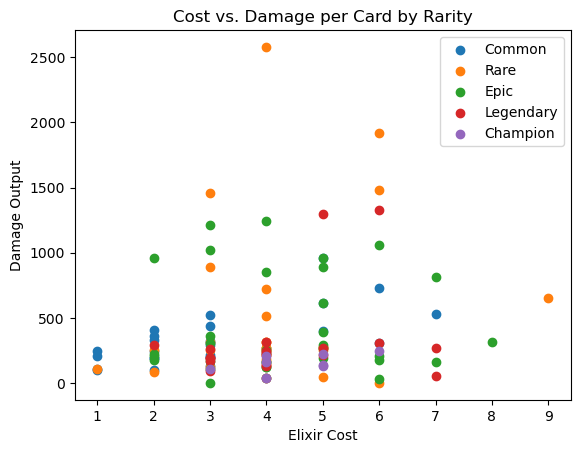

In [81]:
# Graphing bivariate relationships

rarities = ['Common', 'Rare', 'Epic', 'Legendary', 'Champion']
for i in np.arange(5):
    plt.scatter(x = cards.loc[cards['rarity'] == i]['elixirCost'],
                y = cards.loc[cards['rarity'] == i]['damage11'],
                label = rarities[i])
plt.title('Cost vs. Damage per Card by Rarity')
plt.xlabel('Elixir Cost')
plt.ylabel('Damage Output')
plt.legend()
plt.show()

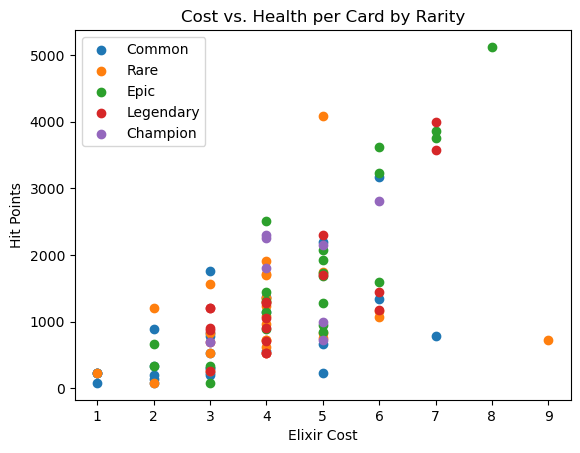

In [78]:
for i in np.arange(5):
    plt.scatter(x = cards.loc[cards['rarity'] == i]['elixirCost'],
                y = cards.loc[cards['rarity'] == i]['hitpoints11'],
                label = rarities[i])
plt.title('Cost vs. Health per Card by Rarity')
plt.xlabel('Elixir Cost')
plt.ylabel('Hit Points')
plt.legend()
plt.show()

In [83]:
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.model_selection import train_test_split

In [86]:
cards = cards.dropna()

X = cards[['elixirCost', 'rarity', 'damage11', 'hitpoints11', 'usage', 'wild_both', 'wild_evo', 'wild_hero', 'type_building',
           'type_spell', 'mobility_flying', 'targets_both', 'targets_buildings', 'attack_type_splash', 'groupCard_True']]
y = cards['Win Rate']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 0)

In [88]:
model1 = RidgeCV(alphas = [0.1, 1.0, 10.0]).fit(X_train, y_train)

array([[2.94081114e+01, 2.64730765e+01, 1.85312896e+01],
       [4.52157152e+00, 3.85929143e+00, 1.78101652e+00],
       [2.96095885e+00, 3.72665095e+00, 7.94372163e+00],
       [9.04217437e+00, 8.05373639e+00, 4.40666902e+00],
       [8.22840018e+00, 9.52651928e+00, 1.47826492e+01],
       [6.63608821e+00, 7.65135290e+00, 5.87668278e+00],
       [4.39324400e+01, 4.17865070e+01, 2.83178736e+01],
       [1.92068366e+00, 2.67240611e+00, 4.59530516e+00],
       [1.16432430e+01, 1.07012958e+01, 7.44255161e+00],
       [4.75803581e+01, 4.85080969e+01, 5.04015103e+01],
       [4.91352353e-01, 6.47935910e-01, 1.32913131e+00],
       [1.84116750e-03, 1.67107524e-02, 1.04708272e-01],
       [8.30686302e-01, 1.86185607e-01, 1.35028643e+00],
       [1.01756970e-01, 2.12345560e-01, 1.92880887e+00],
       [1.47081789e+00, 1.49724935e+00, 1.88835402e+00],
       [9.45029622e+00, 1.62293641e+01, 3.13933379e+01],
       [1.06562064e+00, 5.28713703e-01, 7.98835191e-01],
       [1.77432755e+01, 1.89161

In [100]:
model2 = LassoCV(alphas = [0.1, 1.0, 10.0]).fit(X_train, y_train)
model2.coef_

array([-1.71875575e-01,  5.04836134e-01, -8.94632636e-04,  7.90130353e-05,
        1.12050829e-02, -1.72806122e+00, -2.46810650e+00, -0.00000000e+00,
       -1.63105935e+00,  0.00000000e+00,  1.37973558e+00, -1.38304947e-01,
        0.00000000e+00, -1.80462029e-01,  1.07484183e+00])

In [96]:
y_pred1 = model1.predict(X_test)
y_pred2 = model2.predict(X_test)

In [99]:
print(np.mean(y_pred1 - y_test))
np.mean(y_pred2 - y_test)

0.24717771210037742


np.float64(0.3037125863504871)